In [14]:
import xarray as xr
from scipy import io
import numpy as np
import pandas as pd
import seawater as sw
import matplotlib.pyplot as plt

        
def moving_average(x,n, window = "flat"):
    if n%2 == 0:
        n+=1
    N = x.size
    cx = np.full(x.size, np.nan)
    for i in range(N):
        ii = np.arange(i-n//2, i+n//2+1,1)
        if window == "flat":
            ww = np.ones(ii.size)
        elif window == "gauss":
            xx = ii - i
            
            ww = np.exp(- xx**2/(float(n)/4)**2 )
        elif window == "hanning":
            ww = np.hanning(ii.size)
        ww = ww[ (ii>=0) & (ii<N)]
        ii = ii[ (ii>=0) & (ii<N)]
        
        #print(ii)
        kk = np.isfinite(x[ii])
        if np.sum(kk)<0.25*ii.size:
            continue
        cx[i] = np.sum(x[ii[kk]]*ww[kk])/np.sum(ww[kk])
    return cx

dsvmp = io.loadmat("OVIDE2008_processed_VMP6000_rockland_time_response_H10_gamman.mat")
dsctd = xr.open_dataset("CTD2008_GOSHIP_35TH20080610_ctd.nc")

f = np.loadtxt('pos_VMP')
lon_vmp = f[:,1]
lat_vmp = f[:,0]

pres_vmp = dsvmp["pres"][0,:]
print(pres_vmp)

[   0    4    8 ... 6492 6496 6500]


In [7]:
epsilonSH = np.full(dsvmp["epsSH1"].shape, np.nan)
ii1 = (dsvmp["epsSH1"]<=2.7*dsvmp["epsSH2"]) | (np.isnan(dsvmp["epsSH2"]))
ii2 = (dsvmp["epsSH2"]<=2.7*dsvmp["epsSH1"])| (np.isnan(dsvmp["epsSH1"]))
ii3 = ~((ii1)| (ii2))
epsilonSH[ii1] = dsvmp["epsSH1"][ii1]
epsilonSH[ii2] = dsvmp["epsSH2"][ii2]
epsilonSH[ii3] = 0.5*dsvmp["epsSH2"][ii3]+0.5*dsvmp["epsSH1"][ii3]

#epsilonSH = epsilonSH[3:,:]

In [8]:
epsilonT = np.full(dsvmp["epsT1"].shape, np.nan)
ii1 = (dsvmp["epsT1"]<=2.7*dsvmp["epsT2"]) | (np.isnan(dsvmp["epsT2"]))
ii2 = (dsvmp["epsT2"]<=2.7*dsvmp["epsT1"])| (np.isnan(dsvmp["epsT1"]))
ii3 = ~((ii1)| (ii2))
epsilonT[ii1] = dsvmp["epsT1"][ii1]
epsilonT[ii2] = dsvmp["epsT2"][ii2]
epsilonT[ii3] = 0.5*dsvmp["epsT2"][ii3]+0.5*dsvmp["epsT1"][ii3]

#epsilonT = epsilonT

In [9]:
epsilon = np.copy(epsilonT)
epsilon[epsilonSH>1e-9] = epsilonSH[epsilonSH>1e-9]

In [10]:
dsvmp["Xif2"][:,20] = np.nan

chif = np.full(dsvmp["Xif1"].shape, np.nan)
ii1 = (dsvmp["Xif1"]<=2.7*dsvmp["Xif2"]) | (np.isnan(dsvmp["Xif2"])) | (dsvmp["Xif2"]==0) 
ii2 = (dsvmp["Xif2"]<=2.7*dsvmp["Xif1"]) | (np.isnan(dsvmp["Xif1"])) | (dsvmp["Xif1"]==0) 
ii3 = ~((ii1)| (ii2))
chif[ii1] = dsvmp["Xif1"][ii1]
chif[ii2] = dsvmp["Xif2"][ii2]
chif[ii3] = 0.5*dsvmp["Xif1"][ii3]+0.5*dsvmp["Xif2"][ii3]

chif = chif

In [11]:
dsvmp["Xic2"][:,20] = np.nan

chic = np.full(dsvmp["Xic1"].shape, np.nan)
ii1 = (dsvmp["Xic1"]<=2.7*dsvmp["Xic2"]) | (np.isnan(dsvmp["Xic2"])) | (dsvmp["Xic2"]==0) 
ii2 = (dsvmp["Xic2"]<=2.7*dsvmp["Xic1"]) | (np.isnan(dsvmp["Xic1"])) | (dsvmp["Xic1"]==0) 
ii3 = ~((ii1)| (ii2))
chic[ii1] = dsvmp["Xic1"][ii1]
chic[ii2] = dsvmp["Xic2"][ii2]
chic[ii3] = 0.5*dsvmp["Xic1"][ii3]+0.5*dsvmp["Xic2"][ii3]

chic = chic

In [12]:
chi = np.copy(chif)
chi[epsilonSH>1e-9] = chic[epsilonSH>1e-9]
chi[chif==0] = chic[chif==0]

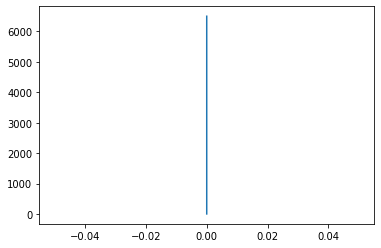

In [15]:
plt.plot( chi[:,13]==0,pres_vmp)

In [16]:
print(chi.shape)

(1626, 30)


In [17]:

pres2d = np.tile(dsvmp["pres"][0,:],(30,1)).T.astype(float)
dsvmp["pres2d"] = pres2d
dsvmp["epsilon"] = epsilon
dsvmp["chi"] = chi
dsvmp["longitude"] = lon_vmp
dsvmp["latitude"] = lat_vmp
io.savemat("OVIDE2008_processed_VMP6000_final.mat",dsvmp)